# Plotting PSDs

In this notebook we generate the Figure 1 and Figure 2 plots for use in the paper. The PSDs and characteristic strains have been generated in estimate_psds.sh and characteristic_strain.sh respectively, so we will load them in

In [1]:
import pycbc.psd
import numpy as np

from matplotlib import pyplot as plt
plt.style.use('../paper.mplstyle')

paper_plot_dir = '../paper/images/dataset'

import ldc.lisa.noise.noise as ldc_noise

import sys
import os

search_dir = os.path.abspath("../search")

if search_dir not in sys.path:
    sys.path.insert(0, search_dir)

import plotting_utils

import h5py
cutoff_days = [0.5, 1, 4, 7, 14]

# Bounds of the smoothed (bridged) section in Hz - must match estimate_psds.py
section_lower, section_upper = 0.03, 0.09


def load_psd(filename, flen, delta_f):
    return  pycbc.psd.from_txt(
        filename,
        flen,
        delta_f,
        delta_f,
        is_asd_file=False
    )



/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version 

In [2]:
# Load in PSD files
duration = 365 * 86400
delta_t = 5
flen = int(duration / delta_t) // 2 + 1
delta_f = 1 / duration

estimated_format = '{channel}_sangria_hm_PSD.txt'
A_estimate = load_psd(estimated_format.format(channel='A'), flen=flen, delta_f=delta_f)
T_estimate = load_psd(estimated_format.format(channel='T'), flen=flen, delta_f=delta_f)

smoothed_estimated_format = '{channel}_sangria_hm_SMOOTHED_PSD.txt'
A_smoothed = load_psd(smoothed_estimated_format.format(channel='A'), flen=flen, delta_f=delta_f)
# The noise-only residual PSDs (data with every signal type removed).
residual_A_psd = load_psd('residual_A_sangria_hm_PSD.txt', flen=flen, delta_f=delta_f)
residual_E_psd = load_psd('residual_E_sangria_hm_PSD.txt', flen=flen, delta_f=delta_f)

AE_model = load_psd('model_AE_PSD.txt', flen=flen, delta_f=delta_f)
T_model = load_psd('model_T_PSD.txt', flen=flen, delta_f=delta_f)

AE_model_nogb = load_psd('model_AE_NOGB_PSD.txt', flen=flen, delta_f=delta_f)

AE_model_smoothed = load_psd('model_AE_SMOOTHED_PSD.txt', flen=flen, delta_f=delta_f)

/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/psd/read.py:76: RuntimeWarning: divide by zero encountered in log
  slog = numpy.log(noise_data)


Now make the PSD plot - no smoothing

In [3]:
def plot_psd_lines(ax):
    lines_to_plot = (
        (A_estimate, 'A Estimated', 'tab:orange', '-'),
        (T_estimate, 'T Estimated', 'tab:blue', '-'),
        (AE_model, 'Model A/E', 'tab:green', '-'),
        (T_model, 'Model T', 'tab:red', '-'),
        (AE_model_nogb, 'Model A/E, no GBs', 'k', ':'),
    )

    for psd, label, c, linestyle in lines_to_plot:

        ax.loglog(
            psd.sample_frequencies,
            psd,
            c=c,
            label=label,
            linestyle=linestyle,
            rasterized=True,
        )

    smoothed_section_upper = 0.09
    smoothed_section_lower = 0.03

    smoothed_lines = [
        (A_smoothed, 'A Smoothed', 'tab:pink', '-'),
        (AE_model_smoothed, 'Model A/E Smoothed', 'k', '--'),
    ]
    for psd, label, c, linestyle in smoothed_lines:
        idx_min = np.argmin(abs(psd.sample_frequencies - smoothed_section_lower))
        idx_max = np.argmin(abs(psd.sample_frequencies - smoothed_section_upper))
        ax.loglog(
            psd.sample_frequencies[idx_min:idx_max],
            psd[idx_min:idx_max],
            c=c,
            label=label,
            linestyle=linestyle,
            rasterized=True,
        )


    ax.axvspan(
        0.03, 0.09,
        color='gray', zorder=-100, label='Smoothed Section', alpha=0.2
    )

    return ax.legend(loc='upper left')



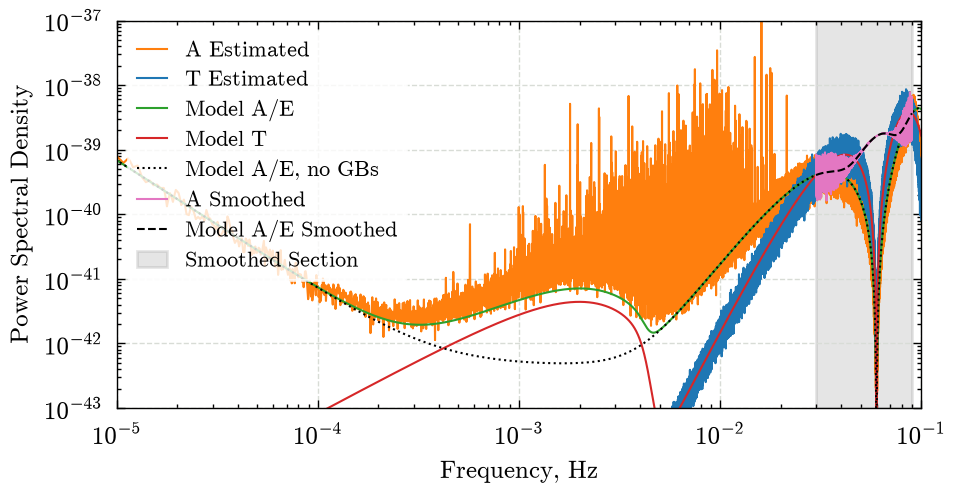

In [4]:
width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))

leg1 = plot_psd_lines(ax)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-5, 1e-1])
ax.grid(zorder=-100)

# PSDs money plot (Figure 1)

But we want to get a bit more information out: do Massive black hole binaries clash with the galactic binary background when analysing them pre-merger?

So lets have a look at the charcteristic strain. First we load it in, then add to the PSDs plot that we made above:

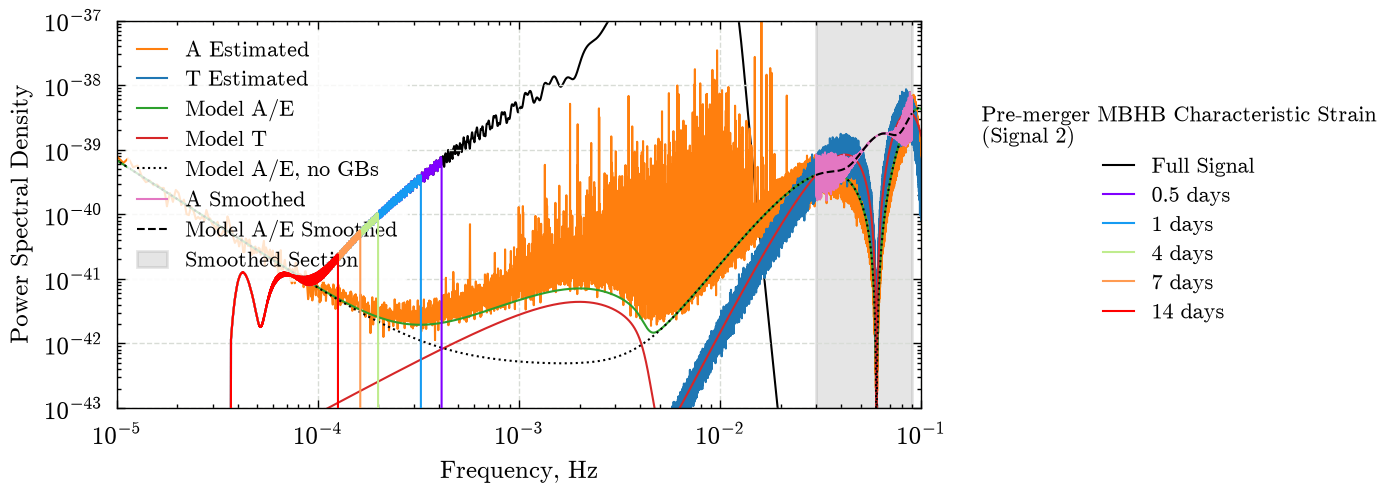

In [5]:
time_before_colors = plotting_utils.get_colors(cutoff_days)
time_before_colors[0] = 'k'

paper_example_signal = 2

width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))

leg1 = plot_psd_lines(ax)

with h5py.File('characteristic_strain/collected_characteristic_strain.hdf', 'r') as ccsf:
    freqs = ccsf['frequencies'][:]
    valid = freqs > 0
    freqs = freqs[valid]

    full_char = np.sqrt(ccsf[str(paper_example_signal)]['0_A'][valid] ** 2 + ccsf[str(paper_example_signal)]['0_E'][valid] ** 2)
    char = {
        days: np.sqrt(ccsf[str(paper_example_signal)][str(days).replace('.','p') + '_A'][valid] ** 2 + 
                    ccsf[str(paper_example_signal)][str(days).replace('.','p') + '_E'][valid] ** 2)
        for days in cutoff_days
    }


line2 = []
labels2 = []

ax.loglog(
    freqs,
    full_char ** 2 / freqs,
    c='k',
    zorder=-90,
    rasterized=True
)
line2.append(
    ax.loglog(
        [],
        [],
        color='k',
    )[0]
)
labels2.append('Full Signal')
for days in cutoff_days:

    ax.loglog(
        freqs,
        char[days] ** 2 / freqs,
        color=time_before_colors[days],
        label=f'{days} days',
        zorder=40+days,
        rasterized=True
    )
    line2.append(
        ax.loglog(
            [],
            [],
            color=time_before_colors[days],
        )[0]
    )
    labels2.append(f'{days} days' if days > 0 else 'Full Signal')

leg2 = ax.legend(
    line2,
    labels2,
    loc="center left",
    title=f"Pre-merger MBHB Characteristic Strain\n(Signal {paper_example_signal})",
    bbox_to_anchor=(1.05,0.5),
)
ax.add_artist(leg1)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-5, 1e-1])
ax.grid(zorder=-100)

fig.savefig(f'{paper_plot_dir}/figure_1_psds_with_sources.png')


Well thats nice, until around 3-4 days before merger, (for most signals) the MBHB strain is completely separate from the galactic binary foreground. Even at 0-5 & 1 day before merger, it is well below the MBHB signal.

This is important to show that this isnt a 'global fit' problem, and we can do this search without significantly worrying about removing the galactic white dwarf binary foregound from the data 🥳🎉🎊

## Load and plot the "smoothing section"

To demonstrate what we are trying to do with the smoothing, we show the model PSD, and the peak either side of it. To use nicer numbers, we round these to 1sf and plot the difference that this makes (practically none)

[0.03497539 0.09725923]


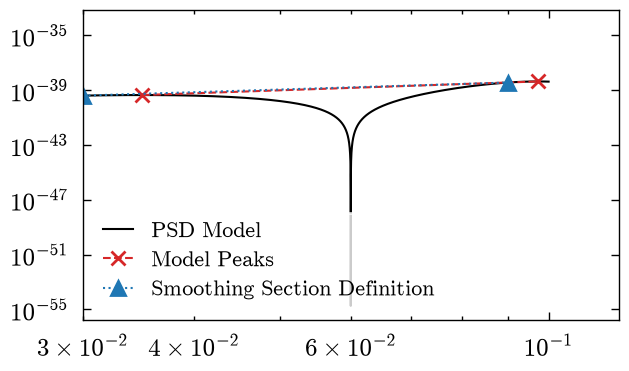

In [6]:
from scipy.signal import find_peaks

pks = find_peaks(
    np.where(
        np.logical_and(
            AE_model.sample_frequencies > 0.01,
            AE_model.sample_frequencies < 0.1
        ),
        AE_model,
        0
    )
)[0]

# We will use 0.03 and 0.09 as the bounds of the section. 
section_lower, section_upper = 0.03, 0.09
print(AE_model.sample_frequencies[pks])
smoothing_window_bound_idxs = np.array((
    np.argmin(
        abs(AE_model.sample_frequencies - section_lower)
    ), 
    np.argmin(
        abs(AE_model.sample_frequencies - section_upper)
    ), 
))

fig, ax = plt.subplots(1, figsize=plt.rcParams["figure.figsize"])
plt.loglog(
    AE_model.sample_frequencies,
    AE_model,
    color='k',
    label="PSD Model"
)
plt.plot(
    AE_model.sample_frequencies[pks],
    AE_model[pks],
    linestyle='--',
    marker='x',
    color='tab:red',
    label='Model Peaks'
)
plt.plot(
    AE_model.sample_frequencies[smoothing_window_bound_idxs],
    AE_model[smoothing_window_bound_idxs],
    linestyle=':',
    marker='^',
    color='tab:blue',
    label="Smoothing Section Definition"
)



plt.xlim(0.03, 0.12)
plt.legend(loc='lower left')

# Now make the smoothed section plot (Figure 2)

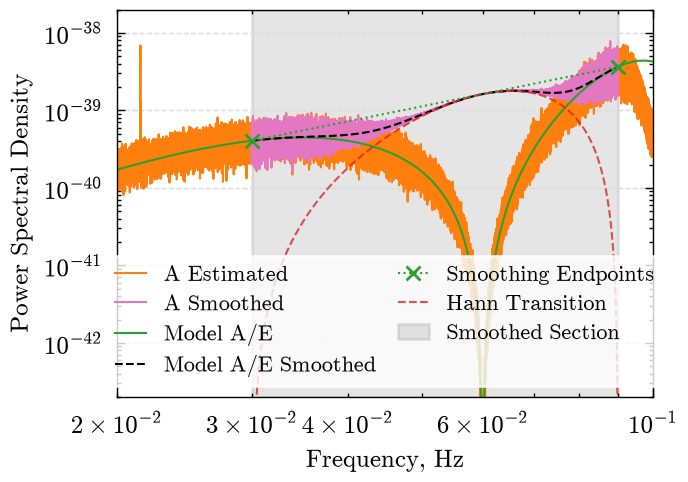

In [7]:
width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1] * 1.25
# Lets plot the PSDs to compare them:
fig, ax = plt.subplots(1, figsize=(width, height))


lines_to_plot = (
    (A_estimate, 'A Estimated', 'tab:orange', '-', None, None),
    (A_smoothed, 'A Smoothed', 'tab:pink', '-', section_lower, section_upper),
    (AE_model, 'Model A/E', 'tab:green', '-', None, None),
    (AE_model_smoothed, 'Model A/E Smoothed', 'k', '--', section_lower, section_upper),
)

for (psd, label, color, linestyle, freqmin, freqmax) in lines_to_plot:
    if freqmin is not None:
        idx_min = np.argmin(abs(psd.sample_frequencies - freqmin))
    else:
        idx_min = None
    if freqmax is not None:
        idx_max = np.argmin(abs(psd.sample_frequencies - freqmax))
    else:
        idx_max = None
    ax.loglog(
        psd.sample_frequencies[idx_min:idx_max],
        psd[idx_min:idx_max],
        label=label,
        color=color,
        linestyle=linestyle,
        rasterized=True
    )




scatter_freqs = [section_lower, section_upper]
scatter_ys = [None, None]
for i, freq in enumerate(scatter_freqs):
    idx = np.argmin(abs(AE_model.sample_frequencies - freq))
    scatter_ys[i] = AE_model[idx]
ax.loglog(
    scatter_freqs, scatter_ys, color='tab:green', marker='x', linestyle=':', zorder=50, label='Smoothing Endpoints'
)

# Plot the Hann window used to smoothly transition between the estimate and the 'bridge'.
# This is the same window applied in smooth_section() (estimate_psds.py).
# We multiply it by the bridge line so it sits at the correct scale on the plot.
idx_min = np.argmin(abs(AE_model.sample_frequencies - section_lower))
idx_max = np.argmin(abs(AE_model.sample_frequencies - section_upper))
section_freqs = AE_model.sample_frequencies[idx_min:idx_max]
from scipy.signal import windows
window = windows.hann(section_freqs.data.size)

# Reconstruct the bridge line (same as in smooth_section) to scale the window by.
start_x, start_y = AE_model.sample_frequencies[idx_min], AE_model[idx_min]
end_x, end_y = AE_model.sample_frequencies[idx_max], AE_model[idx_max]
slope = (np.log(end_y) - np.log(start_y)) / (np.log(end_x) - np.log(start_x))
intercept = np.log(start_y) - slope * np.log(start_x)
bridge_line = np.exp(intercept) * (section_freqs ** slope)

ax.loglog(
    section_freqs,
    window * bridge_line,
    color='tab:red',
    linestyle='--',
    alpha=0.8,
    label="Hann Transition"
)

ax.axvspan(
    section_lower, section_upper,
    color='gray', zorder=-100, label='Smoothed Section', alpha=0.2
)


ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.legend(loc='lower center', ncol=2)
ax.set_ylim([2e-43, 2e-38])
ax.set_xlim([2e-2, 1e-1])
ax.grid(zorder=-100)

fig.savefig('../paper/images/dataset/figure_2_smoothing_60mHz.png')